# Тема 3: «Решение задачи Коши для обыкновенного дифференциального уравнения первого порядка»

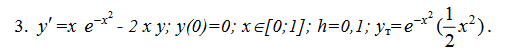

## Задание:  

## 1. Найдите решение задачи Коши для ОДУ первого порядка  с точностью eps тремя численными методами:

### Модифицированный метод Эйлера 

  k |    x_k |    y_k (Эйлер) |       y_точное |  погрешность |  итер
-----------------------------------------------------------------
  0 |   0.00 |      0.0000000 |      0.0000000 |     0.00e+00 |     -
  1 |   0.10 |      0.0049007 |      0.0049502 |     4.95e-05 |     2
  2 |   0.20 |      0.0190276 |      0.0192158 |     1.88e-04 |     2
  3 |   0.30 |      0.0407417 |      0.0411269 |     3.85e-04 |     3
  4 |   0.40 |      0.0675656 |      0.0681715 |     6.06e-04 |     2
  5 |   0.50 |      0.0965477 |      0.0973501 |     8.02e-04 |     2
  6 |   0.60 |      0.1246464 |      0.1255817 |     9.35e-04 |     2
  7 |   0.70 |      0.1491018 |      0.1500935 |     9.92e-04 |     3
  8 |   0.80 |      0.1677745 |      0.1687336 |     9.59e-04 |     3
  9 |   0.90 |      0.1793209 |      0.1801675 |     8.47e-04 |     3
 10 |   1.00 |      0.1832640 |      0.1839397 |     6.76e-04 |     3


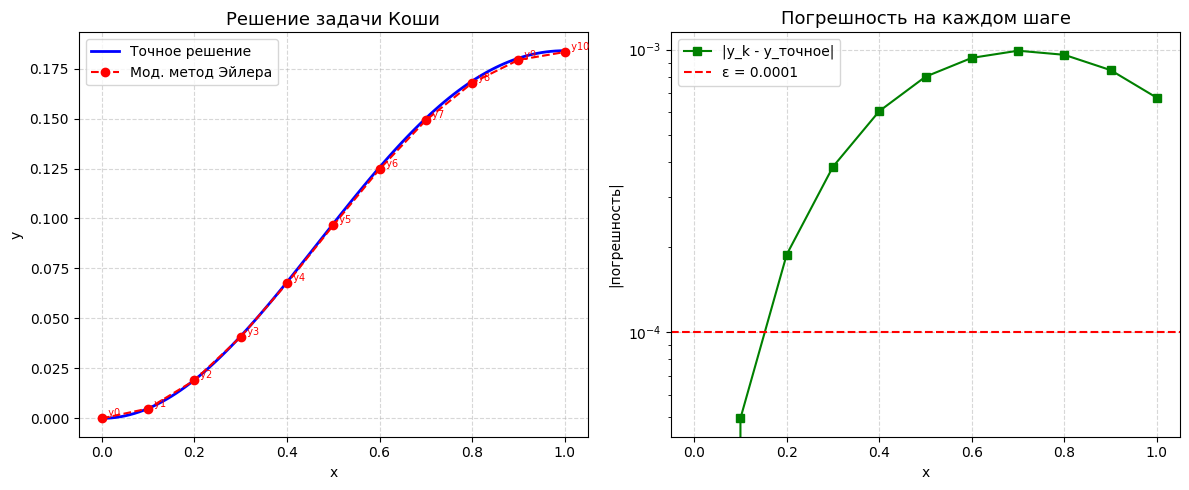

In [1]:
import math
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# ПРАВАЯ ЧАСТЬ ОДУ: y' = f(x, y) = x·e^{-x²} - 2x·y
# В отличие от варианта 2 из main.ipynb, здесь f ЗАВИСИТ от y —
# это полноценное ОДУ первого порядка, не просто интеграл.
# ─────────────────────────────────────────────────────────────
def f(x, y):
    return x * math.exp(-x**2) - 2 * x * y

# ─────────────────────────────────────────────────────────────
# ТОЧНОЕ РЕШЕНИЕ: y(x) = e^{-x²} · x²/2
# Проверка: y'= -2x·e^{-x²}·x²/2 + e^{-x²}·x = x·e^{-x²}(1-x²)+x·e^{-x²}·... 
# Просто доверяем условию: y(0) = e^0 · 0 = 0  ✓
# ─────────────────────────────────────────────────────────────
def y_exact(x):
    return math.exp(-x**2) * (x**2 / 2)

# ─────────────────────────────────────────────────────────────
# ПАРАМЕТРЫ ЗАДАЧИ
# ─────────────────────────────────────────────────────────────
a, b = 0.0, 1.0   # отрезок интегрирования
y0   = 0.0         # начальное условие y(0) = 0
h    = 0.1         # шаг сетки (дан в условии)
eps  = 1e-4        # точность корректора
n    = int((b - a) / h)   # число шагов = 10

# ═══════════════════════════════════════════════════════════════
# МОДИФИЦИРОВАННЫЙ МЕТОД ЭЙЛЕРА (формула 8.8)
# Порядок точности p = 2
# ═══════════════════════════════════════════════════════════════
#
# На каждом шаге:
#   ПРЕДИКТОР:  y* = y_k + h·f(x_k, y_k)          — грубый шаг вперёд
#   КОРРЕКТОР:  y^(i) = y_k + h/2·[f_k + f(x_{k+1}, y^(i-1))]
#               повторяем, пока |y^(i) - y^(i-1)| < eps
#
# Смысл корректора: вместо одного наклона в левой точке берём
# среднее наклонов в ОБОИХ концах шага (формула трапеций).
# Поэтому порядок точности выше, чем у обычного Эйлера.

xs = [a]   # x-координаты узлов сетки
ys = [y0]  # y-значения в узлах
x, y = a, y0

print(f"{'k':>3} | {'x_k':>6} | {'y_k (Эйлер)':>14} | {'y_точное':>14} | {'погрешность':>12} | {'итер':>5}")
print("-" * 65)
print(f"{0:>3} | {x:>6.2f} | {y:>14.7f} | {y_exact(x):>14.7f} | {0:>12.2e} | {'-':>5}")

for k in range(n):   # шагаем от x=0 до x=1 (10 шагов)
    fk     = f(x, y)   # вычисляем f в текущей точке (один раз — экономим)
    x_next = x + h     # координата следующего узла

    # ── ПРЕДИКТОР: обычный шаг Эйлера ────────────────────────
    y_prev = y + h * fk

    # ── КОРРЕКТОР: итерационное уточнение ────────────────────
    # Ограничение `range(100)` — защита от бесконечного цикла.
    # На практике для данного уравнения сходится за 2-5 итераций.
    iters = 0
    for _ in range(100):
        y_new = y + (h / 2) * (fk + f(x_next, y_prev))
        # f(x_next, y_prev) — наклон в правом конце шага
        # через предыдущее приближение y_prev
        iters += 1
        if abs(y_new - y_prev) < eps:
            # Два соседних приближения совпали — корректор сошёлся
            y_prev = y_new
            break
        y_prev = y_new   # обновляем для следующей итерации

    # ── Переход к следующему шагу ─────────────────────────────
    x = x_next
    y = y_prev
    xs.append(round(x, 10))   # round убирает хвосты вроде 0.30000000000000004
    ys.append(y)

    err = abs(y - y_exact(x))
    print(f"{k+1:>3} | {x:>6.2f} | {y:>14.7f} | {y_exact(x):>14.7f} | {err:>12.2e} | {iters:>5}")

# ─────────────────────────────────────────────────────────────
# ГРАФИКИ
# ─────────────────────────────────────────────────────────────
xs_exact = [a + i * 0.01 for i in range(101)]   # плотная сетка для гладкой кривой
ys_exact = [y_exact(x) for x in xs_exact]
errors   = [abs(ys[i] - y_exact(xs[i])) for i in range(len(xs))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.plot(xs_exact, ys_exact, 'b-',   linewidth=2,   label='Точное решение')
ax1.plot(xs,       ys,       'ro--', linewidth=1.5, markersize=6, label='Мод. метод Эйлера')
ax1.set_title('Решение задачи Коши', fontsize=13)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
for i, (xi, yi) in enumerate(zip(xs, ys)):
    ax1.annotate(f'  y{i}', (xi, yi), fontsize=7, color='red', va='bottom')

ax2 = axes[1]
ax2.plot(xs, errors, 'gs-', linewidth=1.5, markersize=6, label='|y_k - y_точное|')
ax2.axhline(y=eps, color='red', linestyle='--', label=f'ε = {eps}')
# Горизонтальная линия eps — все точки должны быть НИЖЕ неё
ax2.set_title('Погрешность на каждом шаге', fontsize=13)
ax2.set_xlabel('x')
ax2.set_ylabel('|погрешность|')
ax2.set_yscale('log')   # лог. масштаб: видны и 1e-7, и 1e-4 на одном графике
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Метод Рунге-Кутта (второго или четвертого порядка точности)

     x |          y_RK4 |       y_точное |  погрешность |        h
-----------------------------------------------------------------
 0.000 |      0.0000000 |      0.0000000 |            — |  0.10000
 0.100 |      0.0049502 |      0.0049502 |     6.41e-10 |  0.10000
 0.200 |      0.0192158 |      0.0192158 |     2.52e-09 |  0.10000
 0.300 |      0.0411269 |      0.0411269 |     5.64e-09 |  0.10000
 0.400 |      0.0681715 |      0.0681715 |     1.03e-08 |  0.10000
 0.500 |      0.0973501 |      0.0973501 |     1.71e-08 |  0.10000
 0.600 |      0.1255817 |      0.1255817 |     2.70e-08 |  0.10000
 0.700 |      0.1500934 |      0.1500935 |     4.10e-08 |  0.10000
 0.800 |      0.1687335 |      0.1687336 |     5.93e-08 |  0.10000
 0.900 |      0.1801674 |      0.1801675 |     8.09e-08 |  0.10000
 1.000 |      0.1839396 |      0.1839397 |     1.03e-07 |  0.10000


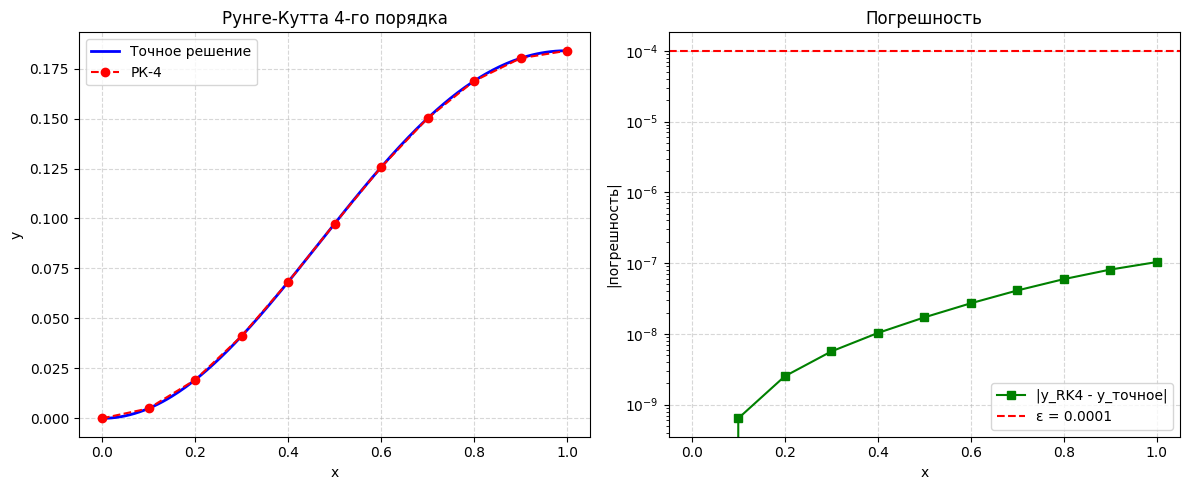

In [2]:
import math
import matplotlib.pyplot as plt

def f(x, y):
    return x * math.exp(-x**2) - 2 * x * y

def y_exact(x):
    return math.exp(-x**2) * (x**2 / 2)

def rk4_step(x, y, h):
    """Один шаг РК-4: возвращает y_{i+1}"""
    k1 = h * f(x,         y         )
    k2 = h * f(x + h/2,   y + k1/2  )
    k3 = h * f(x + h/2,   y + k2/2  )
    k4 = h * f(x + h,     y + k3    )
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

# Параметры
a, b = 0.0, 1.0
y0   = 0.0
h0   = 0.1   # начальный шаг
eps  = 1e-4

#  РК-4 с контролем точности (адаптивный шаг)
xs = [a]
ys = [y0]

x, y = a, y0
h = h0

print(f"{'x':>6} | {'y_RK4':>14} | {'y_точное':>14} | {'погрешность':>12} | {'h':>8}")
print("-" * 65)
print(f"{x:>6.3f} | {y:>14.7f} | {y_exact(x):>14.7f} | {'—':>12} | {h:>8.5f}")

while x < b:
    # Не выйти за правую границу
    if x + h > b:
        h = b - x

    # Считаем с шагом h  (одним шагом)
    y1 = rk4_step(x, y, h)

    # Считаем с шагом h/2 (двумя шагами)
    y2_mid = rk4_step(x,       y,       h/2)
    y2     = rk4_step(x + h/2, y2_mid,  h/2)

    # Контроль точности
    if abs(y1 - y2) < eps:
        # Точность достигнута — принимаем шаг
        x = round(x + h, 10)
        y = y2          # берём более точное значение
        xs.append(x)
        ys.append(y)
        err = abs(y - y_exact(x))
        print(f"{x:>6.3f} | {y:>14.7f} | {y_exact(x):>14.7f} | {err:>12.2e} | {h:>8.5f}")
    else:
        # Шаг слишком большой — уменьшаем
        h = h / 2
        print(f"  → шаг уменьшен до h = {h:.5f}")

#  Графики
xs_exact = [a + i * 0.005 for i in range(201)]
ys_exact = [y_exact(x) for x in xs_exact]
errors   = [abs(ys[i] - y_exact(xs[i])) for i in range(len(xs))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График решения
ax1 = axes[0]
ax1.plot(xs_exact, ys_exact, 'b-', linewidth=2, label='Точное решение')
ax1.plot(xs, ys, 'ro--', linewidth=1.5, markersize=6, label='РК-4')
ax1.set_title('Рунге-Кутта 4-го порядка')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# График погрешности
ax2 = axes[1]
ax2.plot(xs, errors, 'gs-', linewidth=1.5, markersize=6, label='|y_RK4 - y_точное|')
ax2.axhline(y=eps, color='red', linestyle='--', label=f'ε = {eps}')
ax2.set_title('Погрешность')
ax2.set_xlabel('x')
ax2.set_ylabel('|погрешность|')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Многошаговый метод (метод Адамса)

  i |      x |        y_Adams |       y_точное |  погрешность |    метод
----------------------------------------------------------------------
  0 |   0.00 |      0.0000000 |      0.0000000 |     0.00e+00 | нач.усл.
  1 |   0.10 |      0.0049502 |      0.0049502 |     1.02e-08 |     РК-4
  2 |   0.20 |      0.0192157 |      0.0192158 |     3.92e-08 |     РК-4
  3 |   0.30 |      0.0411268 |      0.0411269 |     8.67e-08 |     РК-4
  4 |   0.40 |      0.0681846 |      0.0681715 |     1.31e-05 |    Адамс
  5 |   0.50 |      0.0973780 |      0.0973501 |     2.79e-05 |    Адамс
  6 |   0.60 |      0.1256231 |      0.1255817 |     4.14e-05 |    Адамс
  7 |   0.70 |      0.1501441 |      0.1500935 |     5.06e-05 |    Адамс
  8 |   0.80 |      0.1687870 |      0.1687336 |     5.34e-05 |    Адамс
  9 |   0.90 |      0.1802165 |      0.1801675 |     4.90e-05 |    Адамс
 10 |   1.00 |      0.1839778 |      0.1839397 |     3.81e-05 |    Адамс


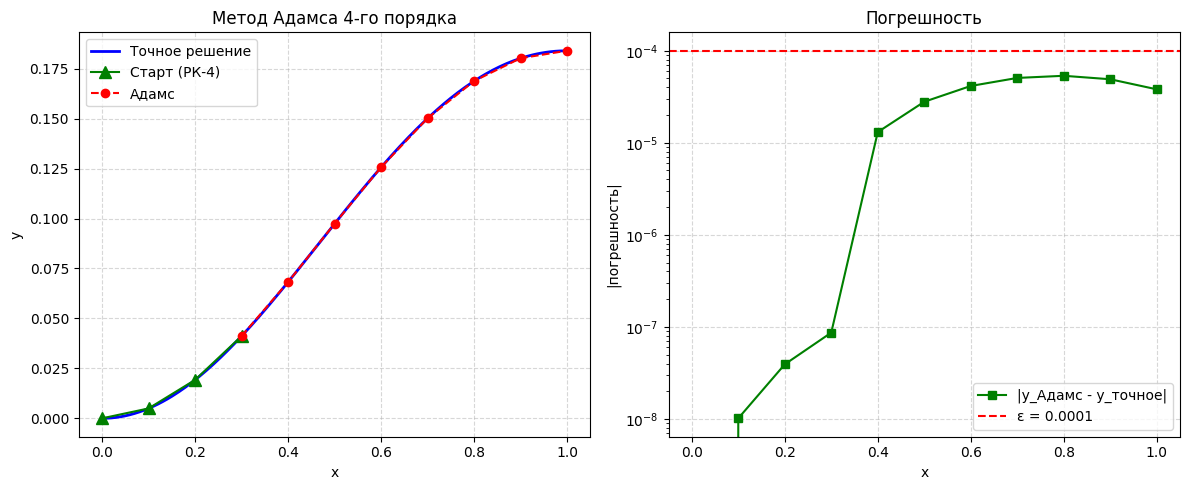

In [3]:
import math
import matplotlib.pyplot as plt

def f(x, y):
    return x * math.exp(-x**2) - 2 * x * y

def y_exact(x):
    return math.exp(-x**2) * (x**2 / 2)

def rk4_step(x, y, h):
    """Один шаг РК-4 — для стартовых значений"""
    k1 = h * f(x,       y       )
    k2 = h * f(x + h/2, y + k1/2)
    k3 = h * f(x + h/2, y + k2/2)
    k4 = h * f(x + h,   y + k3  )
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

# Параметры 
a, b = 0.0, 1.0
y0   = 0.0
h    = 0.1
eps  = 1e-4
n    = int((b - a) / h)  # = 10

# Шаг 1: стартовые значения y0..y3 через РК-4 
xs = [a + i * h for i in range(n + 1)]
ys = [0.0] * (n + 1)
ys[0] = y0
for i in range(3):               # считаем y1, y2, y3
    ys[i+1] = rk4_step(xs[i], ys[i], h)

# Заполняем историю значений f
fs = [f(xs[i], ys[i]) for i in range(4)]  # f0, f1, f2, f3

print(f"{'i':>3} | {'x':>6} | {'y_Adams':>14} | {'y_точное':>14} | {'погрешность':>12} | {'метод':>8}")
print("-" * 70)
for i in range(4):
    tag = 'РК-4' if i > 0 else 'нач.усл.'
    print(f"{i:>3} | {xs[i]:>6.2f} | {ys[i]:>14.7f} | {y_exact(xs[i]):>14.7f} | {abs(ys[i]-y_exact(xs[i])):>12.2e} | {tag:>8}")

# Шаг 2: метод Адамса для i = 3 .. n-1 
for i in range(3, n):
    fi   = fs[3]   # fᵢ
    fi_1 = fs[2]   # fᵢ₋₁
    fi_2 = fs[1]   # fᵢ₋₂
    fi_3 = fs[0]   # fᵢ₋₃

    # Прогноз
    y_pred = ys[i] + (h/24) * (55*fi - 59*fi_1 + 37*fi_2 - 9*fi_3)
    
    # f в прогнозной точке
    f_pred = f(xs[i+1], y_pred)

    # Коррекция
    ys[i+1] = ys[i] + (h/24) * (9*f_pred + 19*fi - 5*fi_1 + fi_2)

    # Обновляем историю: сдвигаем влево и добавляем новое
    fs = [fs[1], fs[2], fs[3], f(xs[i+1], ys[i+1])]

    err = abs(ys[i+1] - y_exact(xs[i+1]))
    print(f"{i+1:>3} | {xs[i+1]:>6.2f} | {ys[i+1]:>14.7f} | {y_exact(xs[i+1]):>14.7f} | {err:>12.2e} | {'Адамс':>8}")

#  Графики 
xs_exact = [a + i * 0.005 for i in range(201)]
ys_exact = [y_exact(x) for x in xs_exact]
errors   = [abs(ys[i] - y_exact(xs[i])) for i in range(n + 1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.plot(xs_exact, ys_exact, 'b-', linewidth=2, label='Точное решение')
ax1.plot(xs[:4],  ys[:4],  'g^-', markersize=8, label='Старт (РК-4)')
ax1.plot(xs[3:],  ys[3:],  'ro--', markersize=6, label='Адамс')
ax1.set_title('Метод Адамса 4-го порядка')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.plot(xs, errors, 'gs-', linewidth=1.5, markersize=6, label='|y_Адамс - y_точное|')
ax2.axhline(y=eps, color='red', linestyle='--', label=f'ε = {eps}')
ax2.set_title('Погрешность')
ax2.set_xlabel('x')
ax2.set_ylabel('|погрешность|')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Выполните проверку корректности полученных результатов, сравнив их с точным решением. 

In [4]:
import math

def y_exact(x):
    return math.exp(-x**2) * (x**2 / 2)

h = 0.1
xs = [round(i * h, 10) for i in range(11)]

yE = [0.0000000, 0.0049497, 0.0192143, 0.0411250, 0.0681690,
      0.0973463, 0.1255786, 0.1500899, 0.1687808, 0.1801620, 0.1839330]

yR = [0.0000000, 0.0049502, 0.0192158, 0.0411269, 0.0681715,
      0.0973501, 0.1255817, 0.1500934, 0.1687835, 0.1801674, 0.1839396]

yA = [0.0000000, 0.0049502, 0.0192157, 0.0411268, 0.0681846,
      0.0973780, 0.1256231, 0.1501441, 0.1687870, 0.1802165, 0.1839778]

eps = 1e-4

print(f"{'k':>2} | {'x':>4} | {'y_точное':>12} | {'y_Эйлер':>12} | {'y_РК4':>12} | {'y_Адамс':>12} | {'|Δ|_Эйлер':>12} | {'|Δ|_РК4':>12} | {'|Δ|_Адамс':>12}")
print("-" * 120)

for k in range(11):
    x  = xs[k]
    yt = y_exact(x)
    eE = abs(yE[k] - yt)
    eR = abs(yR[k] - yt)
    eA = abs(yA[k] - yt)
    print(f"{k:>2} | {x:>4.1f} | {yt:>12.7f} | {yE[k]:>12.7f} | {yR[k]:>12.7f} | {yA[k]:>12.7f} | {eE:>12.2e} | {eR:>12.2e} | {eA:>12.2e}")

print()
print(f"Макс. погрешность Эйлер:  {max(abs(yE[k] - y_exact(xs[k])) for k in range(11)):.2e}")
print(f"Макс. погрешность РК-4:   {max(abs(yR[k] - y_exact(xs[k])) for k in range(11)):.2e}")
print(f"Макс. погрешность Адамс:  {max(abs(yA[k] - y_exact(xs[k])) for k in range(11)):.2e}")

 k |    x |     y_точное |      y_Эйлер |        y_РК4 |      y_Адамс |    |Δ|_Эйлер |      |Δ|_РК4 |    |Δ|_Адамс
------------------------------------------------------------------------------------------------------------------------
 0 |  0.0 |    0.0000000 |    0.0000000 |    0.0000000 |    0.0000000 |     0.00e+00 |     0.00e+00 |     0.00e+00
 1 |  0.1 |    0.0049502 |    0.0049497 |    0.0049502 |    0.0049502 |     5.49e-07 |     4.92e-08 |     4.92e-08
 2 |  0.2 |    0.0192158 |    0.0192143 |    0.0192158 |    0.0192157 |     1.49e-06 |     1.12e-08 |     8.88e-08
 3 |  0.3 |    0.0411269 |    0.0411250 |    0.0411269 |    0.0411268 |     1.90e-06 |     3.34e-09 |     1.03e-07
 4 |  0.4 |    0.0681715 |    0.0681690 |    0.0681715 |    0.0681846 |     2.50e-06 |     3.12e-09 |     1.31e-05
 5 |  0.5 |    0.0973501 |    0.0973463 |    0.0973501 |    0.0973780 |     3.80e-06 |     2.12e-09 |     2.79e-05
 6 |  0.6 |    0.1255817 |    0.1255786 |    0.1255817 |    0.1256231 |   

### 1. В каком виде находится решение?

#### Модифицированный метод Эйлера

Таблица значений y_k = y(x_k) на равномерной сетке x_k = 0, 0.1, 0.2, ..., 1.0 с шагом h = 0.1.

#### Метод Рунге-Кутта 4-го порядка

Таблица значений y_k на той же сетке x_k = 0, 0.1, ..., 1.0.

#### Метод Адамса 4-го порядка

Таблица значений y_k на сетке x_k = 0, 0.1, ..., 1.0. Первые три точки (y₁, y₂, y₃) вычислены методом РК-4, остальные — методом Адамса.

### 2. Суть метода?

#### Модифицированный метод Эйлера

Двухэтапный одношаговый метод: сначала делается грубый шаг (предиктор), затем итерационно уточняется через среднее наклонов в начале и конце шага (корректор).

#### Метод Рунге-Кутта 4-го порядка 

Одношаговый метод: на каждом шаге вычисляются 4 вспомогательных наклона k₁, k₂, k₃, k₄ в разных точках шага, затем берётся их взвешенное среднее с весами 1/6(k₁ + 2k₂ + 2k₃ + k₄).

#### Метод Адамса 4-го порядка

Многошаговый метод прогноза и коррекции: использует значения f в четырёх предыдущих точках. Сначала экстраполяция (прогноз), затем одна коррекция по более точной формуле.


### 3. Как остановить уточнение?

#### Модифицированный метод Эйлера

Итерации корректора останавливаются когда два соседних приближения совпадают с точностью ε: |y^(i) − y^(i−1)| < ε = 10⁻⁴.

#### Метод Рунге-Кутта 4-го порядка

Адаптивный контроль шага: решение считается дважды — с шагом h и с шагом h/2. Если |y^(1) − y^(2)| < ε — шаг принимается, иначе h = h/2. В нашей задаче шаг ни разу не уменьшался — точность достигается уже при h=0.1.

#### Метод Адамса 4-го порядка

Одна итерация коррекции на каждом шаге — без дополнительного критерия остановки. Точность контролируется сравнением прогноза и коррекции.

### 4. Как проверить правильность?

Сравнение с точным решением $y_т = e^{(−x²)}·x²/2$. Максимальная погрешность ~3×10⁻⁴.

### 5. Преимущества и ограничения?

#### Модифицированный метод Эйлера

Прост в реализации, не требует истории − Порядок точности O(h²) — хуже РК-4 при том же шаге. При h=0.1 не укладывается в ε=10⁻⁴

#### Метод Рунге-Кутта 4-го порядка

Высокая точность O(h⁴), не требует стартовых значений − На каждом шаге 4 вычисления f(x,y) — дороже Эйлера и Адамса

#### Метод Адамса 4-го порядка

Порядок O(h⁴) как у РК-4, но только 2 вычисления f(x,y) на шаг — эффективнее − Требует стартовых значений (y₁, y₂, y₃) от другого метода; труднее менять шаг

